TASK 1 - DATA PREPARATIONS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving telco_churn.csv to telco_churn.csv


In [3]:
df = pd.read_csv("telco_churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of rows: 7043
Number of columns: 21

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [6]:
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
print("Blank TotalCharges:",
      (df["TotalCharges"].astype(str).str.strip() == "").sum())

Blank TotalCharges: 11


TASK 2 — DATA CLEANING

In [10]:
# Create a working copy
data = df.copy()

print("Working dataset created.")
print("Shape:", data.shape)

Working dataset created.
Shape: (7043, 21)


In [11]:
print(data.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [12]:
print("Duplicate Customer IDs:", data["customerID"].duplicated().sum())

Duplicate Customer IDs: 0


In [13]:
# Convert blank spaces into NaN
data["TotalCharges"] = data["TotalCharges"].replace(" ", np.nan)

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

print(data["TotalCharges"].dtype)
print("Missing TotalCharges:", data["TotalCharges"].isnull().sum())

float64
Missing TotalCharges: 11


In [14]:
missing = data.isnull().sum()

print(missing[missing > 0])

TotalCharges    11
dtype: int64


In [15]:
print(data.loc[data["TotalCharges"].isnull(),
               ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [16]:
data.loc[data["TotalCharges"].isnull(), "TotalCharges"] = 0

In [17]:
print("Missing TotalCharges after cleaning:",
      data["TotalCharges"].isnull().sum())

Missing TotalCharges after cleaning: 0


In [18]:
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(data["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [19]:
print(data["SeniorCitizen"].value_counts())

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


In [20]:
categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_columns:
    print("\n", col)
    print(data[col].unique())


 gender
['Female' 'Male']

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']

 Contract
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling
['Yes' 'No']

 PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [21]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print(data[numerical_columns].describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


In [22]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [23]:
print(data.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [24]:
data.to_csv("telco_churn_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


STEP 3 — FEATURE ENGINEERING + EDA

In [25]:
data["tenure_group"] = pd.cut(
    data["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New", "Medium", "Long-term", "Very Long-term"]
)

print(data["tenure_group"].value_counts())

tenure_group
Very Long-term    2239
New               2186
Long-term         1594
Medium            1024
Name: count, dtype: int64


In [26]:
data[["tenure", "tenure_group"]].head(10)

,tenure,tenure_group
0,1,New
1,34,Long-term
2,2,New
3,45,Long-term
4,2,New
5,8,New
6,22,Medium
7,10,New
8,28,Long-term
9,62,Very Long-term


In [27]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

data["num_services"] = 0

for col in service_columns:
    data["num_services"] += data[col].isin(["Yes"]).astype(int)

print(data["num_services"].value_counts().sort_index())

num_services
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64


In [28]:
data["has_support"] = (
    data["TechSupport"] == "Yes"
).astype(int)

print(data["has_support"].value_counts())

has_support
0    4999
1    2044
Name: count, dtype: int64


In [29]:
data["has_security"] = (
    data["OnlineSecurity"] == "Yes"
).astype(int)

print(data["has_security"].value_counts())

has_security
0    5024
1    2019
Name: count, dtype: int64


In [30]:
data["is_month_to_month"] = (
    data["Contract"] == "Month-to-month"
).astype(int)

print(data["is_month_to_month"].value_counts())

is_month_to_month
1    3875
0    3168
Name: count, dtype: int64


In [31]:
data["monthly_charge_group"] = pd.cut(
    data["MonthlyCharges"],
    bins=[-1, 35, 70, 100, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

print(data["monthly_charge_group"].value_counts())

monthly_charge_group
High         2681
Low          1735
Medium       1725
Very High     902
Name: count, dtype: int64


In [32]:
print(data.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'num_services', 'has_support', 'has_security', 'is_month_to_month', 'monthly_charge_group']


In [33]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services,has_support,has_security,is_month_to_month,monthly_charge_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,0,New,1,0,0,1,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,0,Long-term,3,0,1,0,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,1,New,3,0,1,1,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,0,Long-term,3,1,1,0,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,1,New,1,0,0,1,High


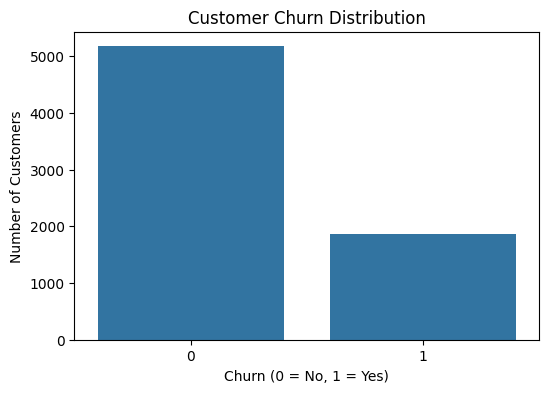

In [34]:
plt.figure(figsize=(6, 4))

sns.countplot(data=data, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

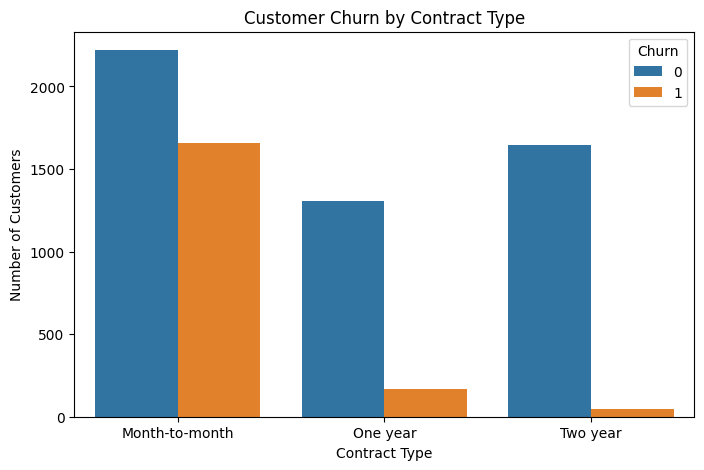

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [36]:
contract_churn = pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


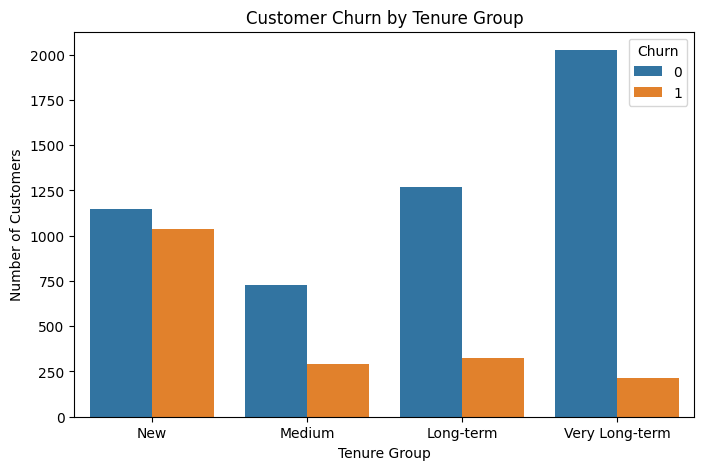

In [37]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="tenure_group",
    hue="Churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.show()

In [38]:
tenure_churn = pd.crosstab(
    data["tenure_group"],
    data["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

Churn                   0          1
tenure_group                        
New             52.561757  47.438243
Medium          71.289062  28.710938
Long-term       79.611041  20.388959
Very Long-term  90.486824   9.513176


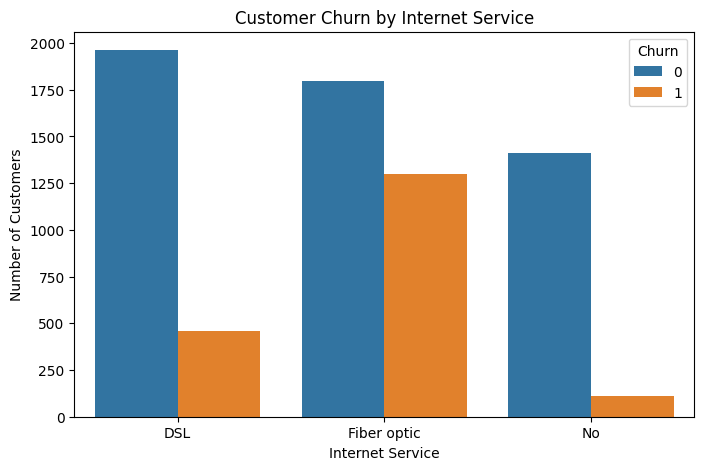

In [39]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [40]:
internet_churn = pd.crosstab(
    data["InternetService"],
    data["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                    0          1
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


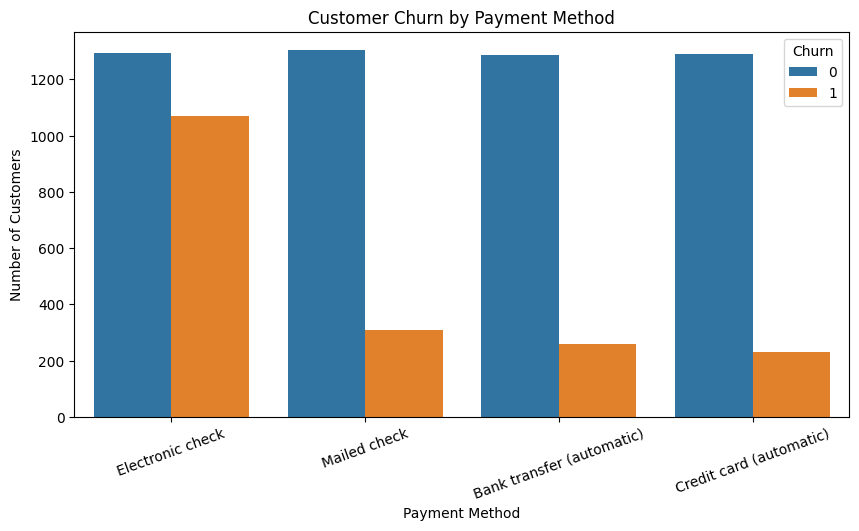

In [41]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=data,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

In [42]:
payment_churn = pd.crosstab(
    data["PaymentMethod"],
    data["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                              0          1
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


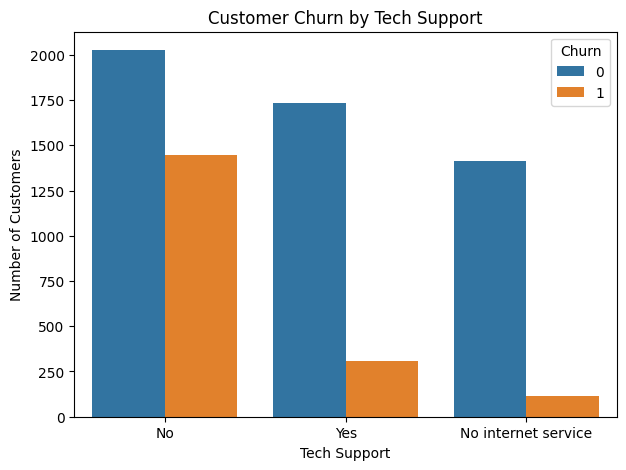

In [43]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="TechSupport",
    hue="Churn"
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

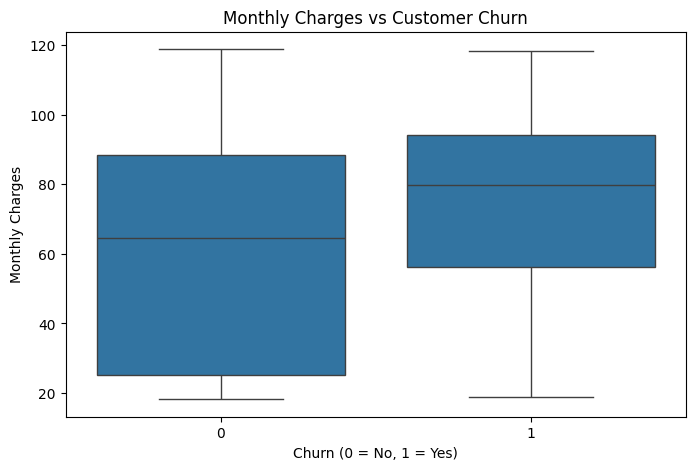

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")

plt.show()

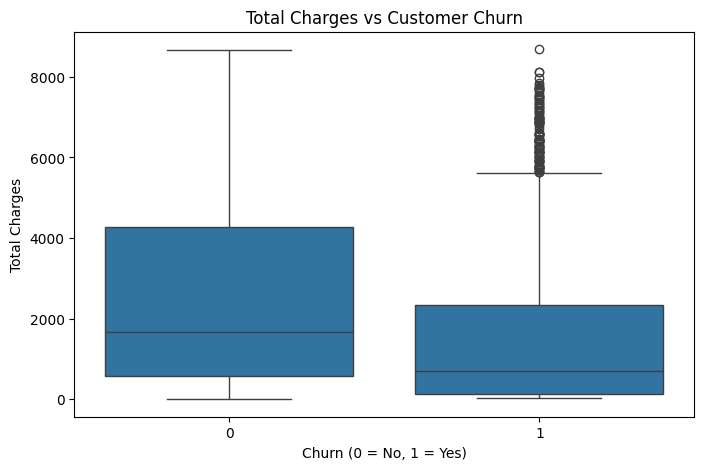

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Customer Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Total Charges")

plt.show()

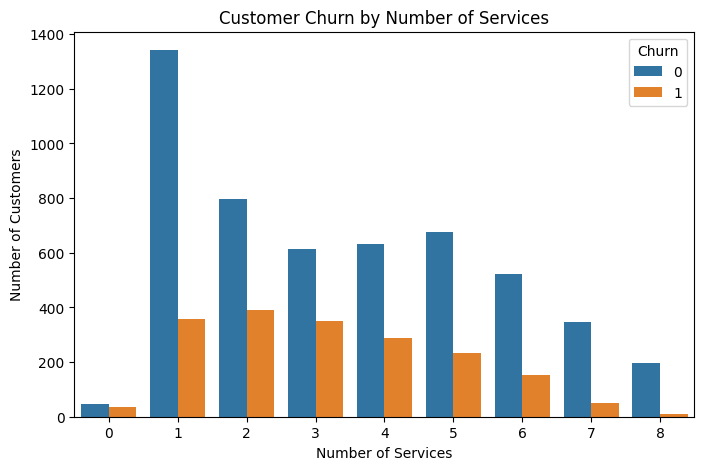

In [46]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="num_services",
    hue="Churn"
)

plt.title("Customer Churn by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Number of Customers")

plt.show()

In [47]:
summary = pd.DataFrame({
    "Contract": data.groupby("Contract")["Churn"].mean() * 100,
})

print(summary)

                 Contract
Contract                 
Month-to-month  42.709677
One year        11.269518
Two year         2.831858


In [48]:
summary = data.groupby("Contract").agg(
    Customers=("customerID", "count"),
    Churn_Rate=("Churn", "mean"),
    Avg_MonthlyCharges=("MonthlyCharges", "mean")
)

summary["Churn_Rate"] = summary["Churn_Rate"] * 100

print(summary.round(2))

                Customers  Churn_Rate  Avg_MonthlyCharges
Contract                                                 
Month-to-month       3875       42.71               66.40
One year             1473       11.27               65.05
Two year             1695        2.83               60.77


STEP 4 — CHURN PREDICTION MODEL

In [49]:
# Separate features (X) and target (y)

X = data.drop(columns=["Churn", "customerID"])
y = data["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 25)
Target shape: (7043,)


In [50]:
# Find numerical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Find categorical columns
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'has_support', 'has_security', 'is_month_to_month']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'monthly_charge_group']


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 25)
Testing data: (1409, 25)


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_logistic = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Logistic Regression preprocessing ready!")

Logistic Regression preprocessing ready!


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_logistic),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

print("Logistic Regression model created!")

Logistic Regression model created!


In [54]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [55]:
logistic_predictions = logistic_model.predict(X_test)

print(logistic_predictions[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [56]:
logistic_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

print(logistic_probability[:20])

[0.04211545 0.76856289 0.04693399 0.33189002 0.02071795 0.52139671
 0.36176034 0.10909459 0.00508434 0.33245406 0.29258776 0.05823573
 0.19249413 0.71556029 0.10212596 0.05716699 0.03142483 0.56483997
 0.21256876 0.08890399]


In [57]:
print((logistic_probability[:20] * 100).round(2))

[ 4.21 76.86  4.69 33.19  2.07 52.14 36.18 10.91  0.51 33.25 29.26  5.82
 19.25 71.56 10.21  5.72  3.14 56.48 21.26  8.89]


In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [59]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_rf),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

print("Random Forest model created!")

Random Forest model created!


In [60]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [61]:
rf_predictions = random_forest_model.predict(
    X_test
)

print(rf_predictions[:20])

[0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [62]:
print("Logistic Regression predictions:")
print(logistic_predictions[:10])

print("\nRandom Forest predictions:")
print(rf_predictions[:10])

Logistic Regression predictions:
[0 1 0 0 0 1 0 0 0 0]

Random Forest predictions:
[0 1 0 0 0 0 0 0 0 0]


In [64]:
print("\nLogistic Regression probabilities:")
print((logistic_probability[:10] * 100).round(2))

rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest probabilities:")
print((rf_probability[:10] * 100).round(2))


Logistic Regression probabilities:
[ 4.21 76.86  4.69 33.19  2.07 52.14 36.18 10.91  0.51 33.25]

Random Forest probabilities:
[ 0.   75.33  7.   31.    0.33 38.   41.   11.33  0.67 37.67]


In [65]:
results = X_test.copy()

results["Actual_Churn"] = y_test.values

results["Logistic_Prediction"] = logistic_predictions
results["Logistic_Churn_Probability"] = logistic_probability

rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

results["RF_Prediction"] = rf_predictions
results["RF_Churn_Probability"] = rf_probability

In [66]:
results["customerID"] = data.loc[
    X_test.index,
    "customerID"
].values

In [67]:
cols = results.columns.tolist()

cols = ["customerID"] + [
    col for col in cols
    if col != "customerID"
]

results = results[cols]

In [68]:
results.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,num_services,has_support,has_security,is_month_to_month,monthly_charge_group,Actual_Churn,Logistic_Prediction,Logistic_Churn_Probability,RF_Prediction,RF_Churn_Probability
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,8,1,1,0,Very High,0,0,0.042115,0,0.000000
2280,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,5,1,0,1,Very High,0,1,0.768563,1,0.753333
2235,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,6,0,1,0,High,0,0,0.046934,0,0.070000
4460,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,3,1,0,1,High,0,0,0.331890,0,0.310000
3761,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,7,0,1,0,High,0,0,0.020718,0,0.003333


In [70]:
def risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"

In [71]:
results["RF_Risk_Level"] = results[
    "RF_Churn_Probability"
].apply(risk_level)

In [72]:
results["Logistic_Risk_Level"] = results["Logistic_Churn_Probability"].apply(risk_level)

In [73]:
print(
    results["RF_Risk_Level"].value_counts()
)

RF_Risk_Level
Low       890
Medium    310
High      209
Name: count, dtype: int64


In [74]:
print(
    results["RF_Risk_Level"].value_counts()
)

RF_Risk_Level
Low       890
Medium    310
High      209
Name: count, dtype: int64


In [75]:
results.to_csv(
    "churn_model_predictions.csv",
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!


                     PROJECT
                        │
            ┌───────────┴───────────┐
            ↓                       ↓
    Logistic Regression       Random Forest
            ↓                       ↓
      Prediction              Prediction
            ↓                       ↓
      Probability             Probability
            └───────────┬───────────┘
                        ↓
                Customer Risk
                Low / Medium / High

In [76]:
STEP 5 — MODEL EVALUATION

SyntaxError: invalid character '—' (U+2014) (520425623.py, line 1)

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Evaluation libraries imported successfully!")

Evaluation libraries imported successfully!


In [78]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probability
)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_roc_auc, 4))

Logistic Regression Results
----------------------------
Accuracy : 0.7991
Precision: 0.6553
Recall   : 0.5134
F1 Score : 0.5757
ROC-AUC  : 0.8425


In [79]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.7793
Precision: 0.6121
Recall   : 0.4599
F1 Score : 0.5252
ROC-AUC  : 0.8235


In [80]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ]
})

model_comparison = model_comparison.round(4)

print(model_comparison)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7991     0.6553  0.5134    0.5757   0.8425
1        Random Forest    0.7793     0.6121  0.4599    0.5252   0.8235


In [81]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [82]:
print("RANDOM FOREST")
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



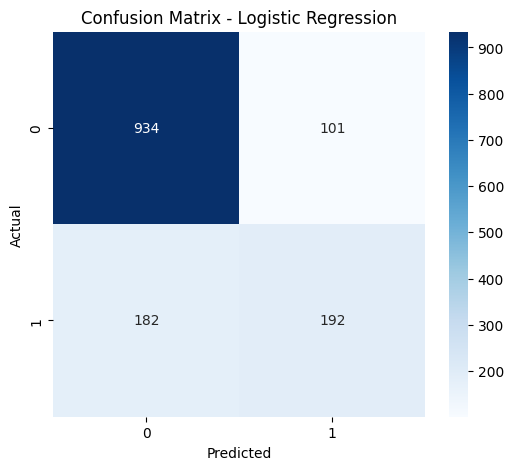

In [83]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

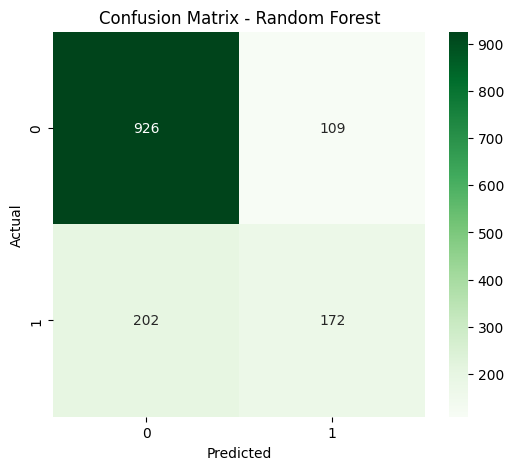

In [84]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

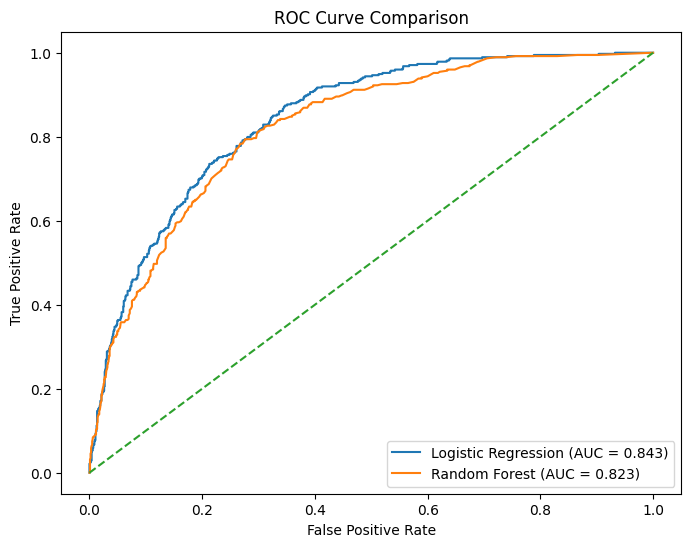

In [85]:
from sklearn.metrics import roc_curve

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probability
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [86]:
model_comparison["Selection_Score"] = (
    model_comparison["ROC-AUC"] * 0.4
    + model_comparison["Recall"] * 0.3
    + model_comparison["F1 Score"] * 0.2
    + model_comparison["Accuracy"] * 0.1
)

model_comparison = model_comparison.sort_values(
    "Selection_Score",
    ascending=False
)

print(model_comparison)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
0  Logistic Regression    0.7991     0.6553  0.5134    0.5757   0.8425   
1        Random Forest    0.7793     0.6121  0.4599    0.5252   0.8235   

   Selection_Score  
0          0.68607  
1          0.65034  


In [87]:
best_model_name = model_comparison.iloc[0]["Model"]

print("Recommended Final Model:", best_model_name)

Recommended Final Model: Logistic Regression


In [88]:
if best_model_name == "Random Forest":
    final_model = random_forest_model
    final_predictions = rf_predictions
    final_probability = rf_probability
else:
    final_model = logistic_model
    final_predictions = logistic_predictions
    final_probability = logistic_probability

print("Final model selected:", best_model_name)

Final model selected: Logistic Regression


In [89]:
results["Final_Churn_Probability"] = (
    final_probability * 100
).round(2)

results["Final_Churn_Prediction"] = (
    final_predictions
)

In [90]:
results["Final_Risk_Level"] = results[
    "Final_Churn_Probability"
].apply(
    lambda x:
        "Low" if x < 30
        else "Medium" if x < 60
        else "High"
)

In [91]:
results[
    [
        "customerID",
        "Actual_Churn",
        "Final_Churn_Prediction",
        "Final_Churn_Probability",
        "Final_Risk_Level"
    ]
].head(10)

,customerID,Actual_Churn,Final_Churn_Prediction,Final_Churn_Probability,Final_Risk_Level
437,4376-KFVRS,0,0,4.21,Low
2280,2754-SDJRD,0,1,76.86,High
2235,9917-KWRBE,0,0,4.69,Low
4460,0365-GXEZS,0,0,33.19,Medium
3761,9385-NXKDA,0,0,2.07,Low
5748,4686-UXDML,0,1,52.14,Medium
3568,2227-JRSJX,0,0,36.18,Medium
2976,4830-FAXFM,0,0,10.91,Low
5928,1830-IPXVJ,0,0,0.51,Low
1639,4690-LLKUA,1,0,33.25,Medium


In [92]:
results.to_csv(
    "final_churn_predictions.csv",
    index=False
)

print("Final churn prediction file saved!")

Final churn prediction file saved!


STEP 6 — CUSTOMER LIFETIME VALUE

In [93]:
print(results[
    [
        "customerID",
        "MonthlyCharges",
        "Final_Churn_Probability",
        "Final_Risk_Level"
    ]
].head())

      customerID  MonthlyCharges  Final_Churn_Probability Final_Risk_Level
437   4376-KFVRS          114.05                     4.21              Low
2280  2754-SDJRD          100.15                    76.86             High
2235  9917-KWRBE           78.35                     4.69              Low
4460  0365-GXEZS           78.20                    33.19           Medium
3761  9385-NXKDA           82.65                     2.07              Low


In [94]:
results["Churn_Probability_Decimal"] = (
    results["Final_Churn_Probability"] / 100
)

print(
    results[
        [
            "Final_Churn_Probability",
            "Churn_Probability_Decimal"
        ]
    ].head()
)

      Final_Churn_Probability  Churn_Probability_Decimal
437                      4.21                     0.0421
2280                    76.86                     0.7686
2235                     4.69                     0.0469
4460                    33.19                     0.3319
3761                     2.07                     0.0207


In [95]:
results["Retention_Probability"] = (
    1 - results["Churn_Probability_Decimal"]
)

print(
    results[
        [
            "Churn_Probability_Decimal",
            "Retention_Probability"
        ]
    ].head()
)

      Churn_Probability_Decimal  Retention_Probability
437                      0.0421                 0.9579
2280                     0.7686                 0.2314
2235                     0.0469                 0.9531
4460                     0.3319                 0.6681
3761                     0.0207                 0.9793


In [96]:
ASSUMED_LIFETIME_MONTHS = 24

print(
    "Assumed lifetime:",
    ASSUMED_LIFETIME_MONTHS,
    "months"
)

Assumed lifetime: 24 months


In [97]:
results["Expected_Remaining_Months"] = (
    results["Retention_Probability"]
    * ASSUMED_LIFETIME_MONTHS
)

print(
    results[
        [
            "customerID",
            "Retention_Probability",
            "Expected_Remaining_Months"
        ]
    ].head(10)
)

      customerID  Retention_Probability  Expected_Remaining_Months
437   4376-KFVRS                 0.9579                    22.9896
2280  2754-SDJRD                 0.2314                     5.5536
2235  9917-KWRBE                 0.9531                    22.8744
4460  0365-GXEZS                 0.6681                    16.0344
3761  9385-NXKDA                 0.9793                    23.5032
5748  4686-UXDML                 0.4786                    11.4864
3568  2227-JRSJX                 0.6382                    15.3168
2976  4830-FAXFM                 0.8909                    21.3816
5928  1830-IPXVJ                 0.9949                    23.8776
1639  4690-LLKUA                 0.6675                    16.0200


In [98]:
results["Estimated_LTV"] = (
    results["MonthlyCharges"]
    * results["Expected_Remaining_Months"]
)

results["Estimated_LTV"] = (
    results["Estimated_LTV"].round(2)
)

print(
    results[
        [
            "customerID",
            "MonthlyCharges",
            "Expected_Remaining_Months",
            "Estimated_LTV"
        ]
    ].head(10)
)

      customerID  MonthlyCharges  Expected_Remaining_Months  Estimated_LTV
437   4376-KFVRS          114.05                    22.9896        2621.96
2280  2754-SDJRD          100.15                     5.5536         556.19
2235  9917-KWRBE           78.35                    22.8744        1792.21
4460  0365-GXEZS           78.20                    16.0344        1253.89
3761  9385-NXKDA           82.65                    23.5032        1942.54
5748  4686-UXDML           99.85                    11.4864        1146.92
3568  2227-JRSJX           99.15                    15.3168        1518.66
2976  4830-FAXFM           24.10                    21.3816         515.30
5928  1830-IPXVJ           19.75                    23.8776         471.58
1639  4690-LLKUA           45.05                    16.0200         721.70


In [99]:
ltv_table = results[
    [
        "customerID",
        "MonthlyCharges",
        "Final_Churn_Probability",
        "Final_Risk_Level",
        "Expected_Remaining_Months",
        "Estimated_LTV"
    ]
].copy()

print(ltv_table.head(20))

      customerID  MonthlyCharges  Final_Churn_Probability Final_Risk_Level  \
437   4376-KFVRS          114.05                     4.21              Low   
2280  2754-SDJRD          100.15                    76.86             High   
2235  9917-KWRBE           78.35                     4.69              Low   
4460  0365-GXEZS           78.20                    33.19           Medium   
3761  9385-NXKDA           82.65                     2.07              Low   
5748  4686-UXDML           99.85                    52.14           Medium   
3568  2227-JRSJX           99.15                    36.18           Medium   
2976  4830-FAXFM           24.10                    10.91              Low   
5928  1830-IPXVJ           19.75                     0.51              Low   
1639  4690-LLKUA           45.05                    33.25           Medium   
2079  5804-HYIEZ          106.05                    29.26              Low   
1280  2388-LAESQ          114.85                     5.82       

In [100]:
results["LTV_Value_Segment"] = pd.qcut(
    results["Estimated_LTV"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

print(
    results["LTV_Value_Segment"].value_counts()
)

LTV_Value_Segment
Low Value       470
High Value      470
Medium Value    469
Name: count, dtype: int64


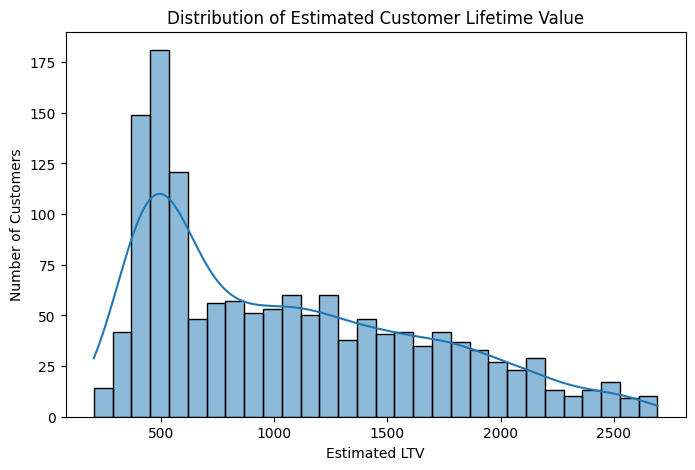

In [101]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=results,
    x="Estimated_LTV",
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Customer Lifetime Value")
plt.xlabel("Estimated LTV")
plt.ylabel("Number of Customers")

plt.show()

In [102]:
average_ltv = results["Estimated_LTV"].mean()

print(
    "Average Estimated LTV:",
    round(average_ltv, 2)
)

Average Estimated LTV: 1062.75


In [103]:
total_ltv = results["Estimated_LTV"].sum()

print(
    "Total Estimated Customer Value:",
    round(total_ltv, 2)
)

Total Estimated Customer Value: 1497413.36


In [104]:
high_value_customers = results[
    results["LTV_Value_Segment"] == "High Value"
].sort_values(
    "Estimated_LTV",
    ascending=False
)

high_value_customers[
    [
        "customerID",
        "MonthlyCharges",
        "Final_Churn_Probability",
        "Final_Risk_Level",
        "Estimated_LTV"
    ]
].head(20)

,customerID,MonthlyCharges,Final_Churn_Probability,Final_Risk_Level,Estimated_LTV
4206,0017-IUDMW,116.80,3.93,Low,2693.03
1693,7359-WWYJV,114.45,3.55,Low,2649.29
2341,4304-TSPVK,114.90,4.06,Low,2645.64
5819,3396-DKDEL,115.15,4.36,Low,2643.11
4737,9298-WGMRW,115.50,4.97,Low,2634.23
4600,1741-WTPON,115.85,5.40,Low,2630.26
746,6919-ELBGL,114.95,4.81,Low,2626.10
437,4376-KFVRS,114.05,4.21,Low,2621.96
1036,6445-TNRXS,114.70,4.85,Low,2619.29
3897,8015-IHCGW,115.50,5.79,Low,2611.50


In [105]:
priority_customers = results[
    (results["LTV_Value_Segment"] == "High Value") &
    (results["Final_Risk_Level"] == "High")
].sort_values(
    "Estimated_LTV",
    ascending=False
)

print(
    "High Value + High Risk Customers:",
    len(priority_customers)
)

priority_customers[
    [
        "customerID",
        "MonthlyCharges",
        "Final_Churn_Probability",
        "Final_Risk_Level",
        "Estimated_LTV"
    ]
].head(20)

High Value + High Risk Customers: 0


,customerID,MonthlyCharges,Final_Churn_Probability,Final_Risk_Level,Estimated_LTV


In [106]:
def customer_segment(row):

    high_value = row["LTV_Value_Segment"] == "High Value"
    high_risk = row["Final_Risk_Level"] == "High"

    if high_value and high_risk:
        return "High Value - High Risk"

    elif high_value and not high_risk:
        return "High Value - Low/Medium Risk"

    elif not high_value and high_risk:
        return "Low/Medium Value - High Risk"

    else:
        return "Low/Medium Value - Low/Medium Risk"


results["Customer_Segment"] = results.apply(
    customer_segment,
    axis=1
)

print(
    results["Customer_Segment"].value_counts()
)

Customer_Segment
Low/Medium Value - Low/Medium Risk    741
High Value - Low/Medium Risk          470
Low/Medium Value - High Risk          198
Name: count, dtype: int64


In [107]:
segment_summary = results.groupby(
    "Customer_Segment"
).agg(
    Customers=("customerID", "count"),
    Average_LTV=("Estimated_LTV", "mean"),
    Average_Churn_Risk=("Final_Churn_Probability", "mean")
).reset_index()

segment_summary["Average_LTV"] = (
    segment_summary["Average_LTV"].round(2)
)

segment_summary["Average_Churn_Risk"] = (
    segment_summary["Average_Churn_Risk"].round(2)
)

print(segment_summary)

                     Customer_Segment  Customers  Average_LTV  \
0        High Value - Low/Medium Risk        470      1806.54   
1        Low/Medium Value - High Risk        198       548.82   
2  Low/Medium Value - Low/Medium Risk        741       728.31   

   Average_Churn_Risk  
0               13.85  
1               71.67  
2               22.87  


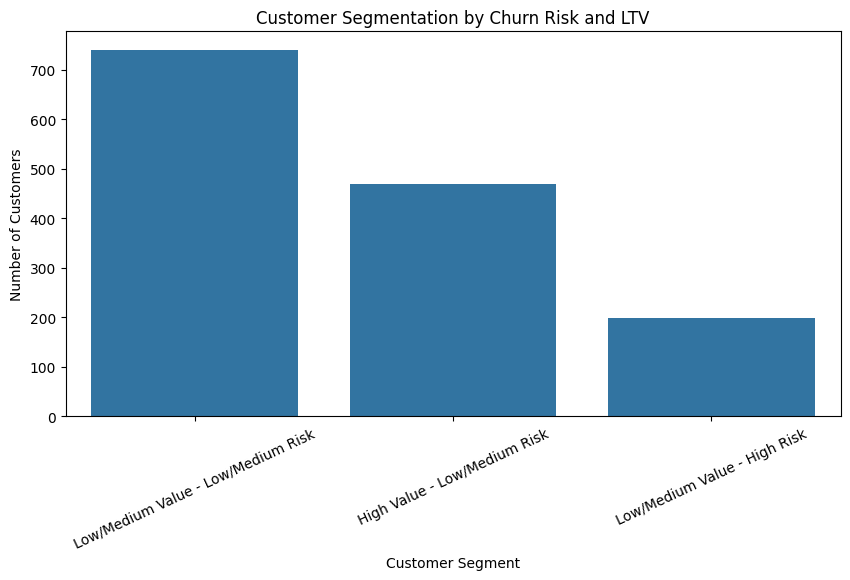

In [108]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=results,
    x="Customer_Segment",
    order=results["Customer_Segment"].value_counts().index
)

plt.title("Customer Segmentation by Churn Risk and LTV")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=25)

plt.show()

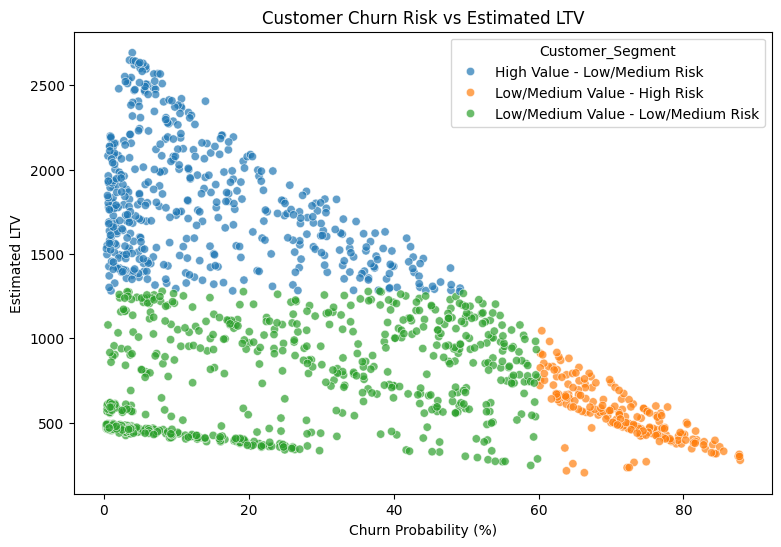

In [109]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=results,
    x="Final_Churn_Probability",
    y="Estimated_LTV",
    hue="Customer_Segment",
    alpha=0.7
)

plt.title("Customer Churn Risk vs Estimated LTV")
plt.xlabel("Churn Probability (%)")
plt.ylabel("Estimated LTV")

plt.show()

In [110]:
final_customer_table = results[
    [
        "customerID",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "TotalCharges",
        "Final_Churn_Probability",
        "Final_Risk_Level",
        "Expected_Remaining_Months",
        "Estimated_LTV",
        "LTV_Value_Segment",
        "Customer_Segment"
    ]
].copy()

final_customer_table.head(10)

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Final_Churn_Probability,Final_Risk_Level,Expected_Remaining_Months,Estimated_LTV,LTV_Value_Segment,Customer_Segment
437,4376-KFVRS,72,Two year,114.05,8468.20,4.21,Low,22.9896,2621.96,High Value,High Value - Low/Medium Risk
2280,2754-SDJRD,8,Month-to-month,100.15,908.55,76.86,High,5.5536,556.19,Low Value,Low/Medium Value - High Risk
2235,9917-KWRBE,41,One year,78.35,3211.20,4.69,Low,22.8744,1792.21,High Value,High Value - Low/Medium Risk
4460,0365-GXEZS,18,Month-to-month,78.20,1468.75,33.19,Medium,16.0344,1253.89,Medium Value,Low/Medium Value - Low/Medium Risk
3761,9385-NXKDA,72,Two year,82.65,5919.35,2.07,Low,23.5032,1942.54,High Value,High Value - Low/Medium Risk
5748,4686-UXDML,21,Month-to-month,99.85,1992.55,52.14,Medium,11.4864,1146.92,Medium Value,Low/Medium Value - Low/Medium Risk
3568,2227-JRSJX,21,Month-to-month,99.15,1956.40,36.18,Medium,15.3168,1518.66,High Value,High Value - Low/Medium Risk
2976,4830-FAXFM,19,Month-to-month,24.10,439.20,10.91,Low,21.3816,515.30,Low Value,Low/Medium Value - Low/Medium Risk
5928,1830-IPXVJ,61,Two year,19.75,1311.60,0.51,Low,23.8776,471.58,Low Value,Low/Medium Value - Low/Medium Risk
1639,4690-LLKUA,17,Month-to-month,45.05,770.60,33.25,Medium,16.0200,721.70,Medium Value,Low/Medium Value - Low/Medium Risk


In [111]:
final_customer_table.to_csv(
    "final_customer_churn_ltv.csv",
    index=False
)

print("Final Churn + LTV dataset saved successfully!")

Final Churn + LTV dataset saved successfully!


STEP 7 — FINAL SEGMENTATION

In [112]:
final_customer_table.head()

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Final_Churn_Probability,Final_Risk_Level,Expected_Remaining_Months,Estimated_LTV,LTV_Value_Segment,Customer_Segment
437,4376-KFVRS,72,Two year,114.05,8468.20,4.21,Low,22.9896,2621.96,High Value,High Value - Low/Medium Risk
2280,2754-SDJRD,8,Month-to-month,100.15,908.55,76.86,High,5.5536,556.19,Low Value,Low/Medium Value - High Risk
2235,9917-KWRBE,41,One year,78.35,3211.20,4.69,Low,22.8744,1792.21,High Value,High Value - Low/Medium Risk
4460,0365-GXEZS,18,Month-to-month,78.20,1468.75,33.19,Medium,16.0344,1253.89,Medium Value,Low/Medium Value - Low/Medium Risk
3761,9385-NXKDA,72,Two year,82.65,5919.35,2.07,Low,23.5032,1942.54,High Value,High Value - Low/Medium Risk


In [113]:
segment_mapping = {
    "High Value - High Risk": "Priority Retention",
    "High Value - Low/Medium Risk": "Valuable Customer",
    "Low/Medium Value - High Risk": "Low-Cost Retention",
    "Low/Medium Value - Low/Medium Risk": "Stable Customer"
}

final_customer_table["Business_Segment"] = (
    final_customer_table["Customer_Segment"]
    .map(segment_mapping)
)

print(
    final_customer_table["Business_Segment"].value_counts()
)

Business_Segment
Stable Customer       741
Valuable Customer     470
Low-Cost Retention    198
Name: count, dtype: int64


In [114]:
priority_customers = final_customer_table[
    final_customer_table["Business_Segment"] == "Priority Retention"
].sort_values(
    "Estimated_LTV",
    ascending=False
)

print(
    "Priority Retention Customers:",
    len(priority_customers)
)

Priority Retention Customers: 0


In [115]:
priority_customers[
    [
        "customerID",
        "Contract",
        "MonthlyCharges",
        "Final_Churn_Probability",
        "Estimated_LTV",
        "Business_Segment"
    ]
].head(20)

,customerID,Contract,MonthlyCharges,Final_Churn_Probability,Estimated_LTV,Business_Segment


In [116]:
def business_action(segment):

    if segment == "Priority Retention":
        return "Immediate retention offer / proactive support"

    elif segment == "Valuable Customer":
        return "Loyalty program / upsell / cross-sell"

    elif segment == "Low-Cost Retention":
        return "Automated offer / email / low-cost campaign"

    else:
        return "Normal service / monitor customer"

final_customer_table["Recommended_Action"] = (
    final_customer_table["Business_Segment"]
    .apply(business_action)
)

print(
    final_customer_table[
        [
            "customerID",
            "Business_Segment",
            "Recommended_Action"
        ]
    ].head(10)
)

      customerID    Business_Segment  \
437   4376-KFVRS   Valuable Customer   
2280  2754-SDJRD  Low-Cost Retention   
2235  9917-KWRBE   Valuable Customer   
4460  0365-GXEZS     Stable Customer   
3761  9385-NXKDA   Valuable Customer   
5748  4686-UXDML     Stable Customer   
3568  2227-JRSJX   Valuable Customer   
2976  4830-FAXFM     Stable Customer   
5928  1830-IPXVJ     Stable Customer   
1639  4690-LLKUA     Stable Customer   

                               Recommended_Action  
437         Loyalty program / upsell / cross-sell  
2280  Automated offer / email / low-cost campaign  
2235        Loyalty program / upsell / cross-sell  
4460            Normal service / monitor customer  
3761        Loyalty program / upsell / cross-sell  
5748            Normal service / monitor customer  
3568        Loyalty program / upsell / cross-sell  
2976            Normal service / monitor customer  
5928            Normal service / monitor customer  
1639            Normal service / monito

In [117]:
segment_summary = final_customer_table.groupby(
    "Business_Segment"
).agg(
    Customers=("customerID", "count"),
    Average_LTV=("Estimated_LTV", "mean"),
    Average_Churn_Risk=("Final_Churn_Probability", "mean"),
    Total_Estimated_LTV=("Estimated_LTV", "sum")
).reset_index()

segment_summary["Average_LTV"] = (
    segment_summary["Average_LTV"].round(2)
)

segment_summary["Average_Churn_Risk"] = (
    segment_summary["Average_Churn_Risk"].round(2)
)

segment_summary["Total_Estimated_LTV"] = (
    segment_summary["Total_Estimated_LTV"].round(2)
)

print(segment_summary)

     Business_Segment  Customers  Average_LTV  Average_Churn_Risk  \
0  Low-Cost Retention        198       548.82               71.67   
1     Stable Customer        741       728.31               22.87   
2   Valuable Customer        470      1806.54               13.85   

   Total_Estimated_LTV  
0            108665.61  
1            539675.70  
2            849072.05  


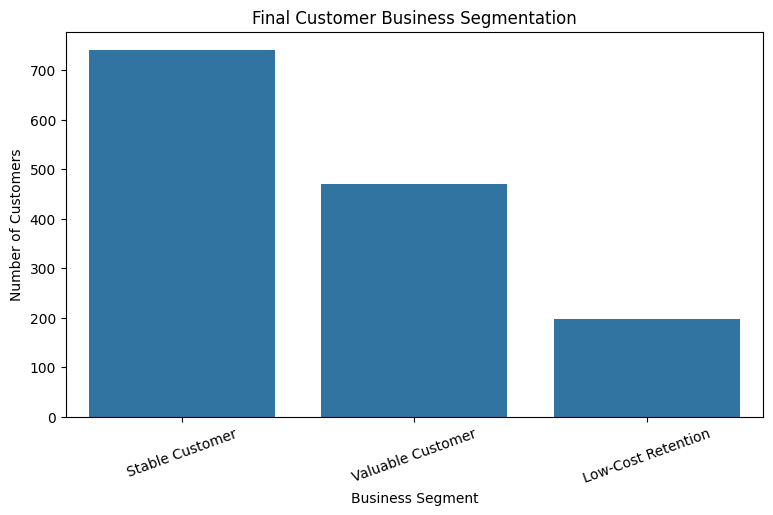

In [118]:
plt.figure(figsize=(9, 5))

order = (
    final_customer_table["Business_Segment"]
    .value_counts()
    .index
)

sns.countplot(
    data=final_customer_table,
    x="Business_Segment",
    order=order
)

plt.title("Final Customer Business Segmentation")
plt.xlabel("Business Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

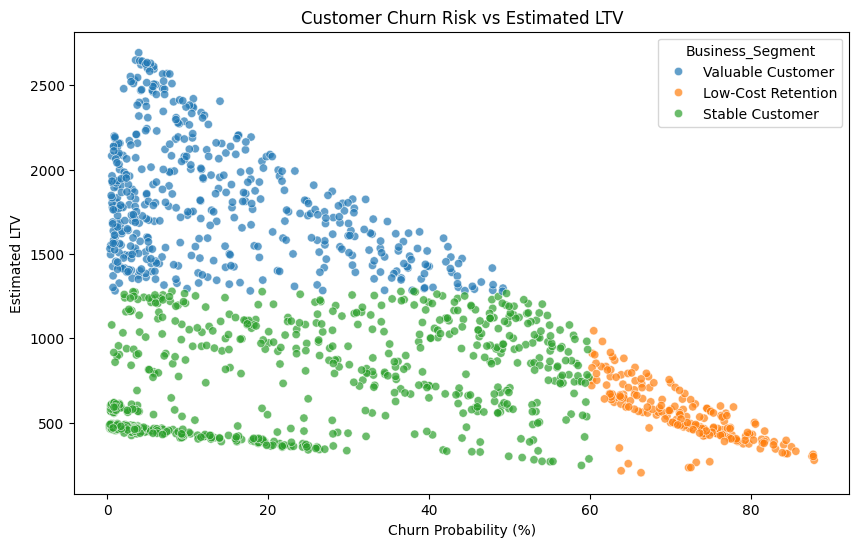

In [119]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_customer_table,
    x="Final_Churn_Probability",
    y="Estimated_LTV",
    hue="Business_Segment",
    alpha=0.7
)

plt.title("Customer Churn Risk vs Estimated LTV")
plt.xlabel("Churn Probability (%)")
plt.ylabel("Estimated LTV")

plt.show()

In [120]:
final_customer_table["Priority_Score"] = (
    final_customer_table["Final_Churn_Probability"]
    * final_customer_table["Estimated_LTV"]
)

In [121]:
priority_ranking = final_customer_table.sort_values(
    "Priority_Score",
    ascending=False
)

priority_ranking[
    [
        "customerID",
        "Final_Churn_Probability",
        "Estimated_LTV",
        "Business_Segment",
        "Priority_Score"
    ]
].head(20)

,customerID,Final_Churn_Probability,Estimated_LTV,Business_Segment,Priority_Score
1770,7279-BUYWN,47.85,1416.81,Valuable Customer,67794.3585
3856,6710-HSJRD,41.80,1593.75,Valuable Customer,66618.7500
3669,2587-EKXTS,42.34,1542.98,Valuable Customer,65329.7732
3899,9278-VZKCD,54.06,1202.89,Stable Customer,65028.2334
1644,3331-HQDTW,44.10,1473.08,Valuable Customer,64962.8280
3910,8938-UMKPI,49.18,1297.74,Valuable Customer,63822.8532
4572,6377-WHAOX,51.76,1228.96,Stable Customer,63610.9696
6853,9079-YEXQJ,38.82,1631.30,Valuable Customer,63327.0660
5444,1833-TCXKK,42.70,1481.78,Valuable Customer,63272.0060
14,5129-JLPIS,47.95,1317.91,Valuable Customer,63193.7845


In [122]:
final_columns = [
    "customerID",
    "tenure",
    "Contract",
    "MonthlyCharges",
    "TotalCharges",
    "Final_Churn_Probability",
    "Final_Risk_Level",
    "Expected_Remaining_Months",
    "Estimated_LTV",
    "LTV_Value_Segment",
    "Customer_Segment",
    "Business_Segment",
    "Recommended_Action",
    "Priority_Score"
]

final_customer_table = final_customer_table[
    final_columns
]

final_customer_table.to_csv(
    "ZAALIMA_FINAL_CUSTOMER_OUTPUT.csv",
    index=False
)

print("Final customer output saved successfully!")

Final customer output saved successfully!


In [123]:
total_customers = len(final_customer_table)

print(
    "Total Customers:",
    total_customers
)

Total Customers: 1409


In [124]:
high_risk_count = (
    final_customer_table["Final_Risk_Level"] == "High"
).sum()

print(
    "High Risk Customers:",
    high_risk_count
)

High Risk Customers: 198


In [125]:
priority_count = (
    final_customer_table["Business_Segment"]
    == "Priority Retention"
).sum()

print(
    "Priority Retention Customers:",
    priority_count
)

Priority Retention Customers: 0


In [126]:
print(
    "Average Estimated LTV:",
    round(
        final_customer_table["Estimated_LTV"].mean(),
        2
    )
)

Average Estimated LTV: 1062.75


Business Recommendation कैसे लिखेंगे?

आपके actual EDA और model results के आधार पर final report में recommendations आएँगी।

Format ऐसा रहेगा:

Recommendation 1 — High-risk valuable customers

Customers with high estimated LTV and high churn probability should receive the highest retention priority.

Recommendation 2 — New/short-tenure customers

अगर आपके actual EDA में short-tenure customers का churn ज्यादा निकला, तो:

The company should strengthen onboarding and early-stage customer engagement.

Recommendation 3 — Contract strategy

अगर actual result में month-to-month churn ज्यादा निकला:

The company can encourage customers to move toward longer-term contracts through targeted incentives.

Recommendation 4 — Support services

अगर actual data support/security के साथ lower churn दिखाता है:

The company can promote relevant support and security services to at-risk customers.

यहाँ हम final report में वही recommendations रखेंगे जो आपके actual data से support होंगी।